Test the architecture

In [37]:
import torch
values = torch.load("Models/Model_Exec_710_Epoch_150_cpu_portable_full.pt", map_location="cpu", weights_only=False)
model = values["modelo"]
print(model)

CNN(
  (extraction): Sequential(
    (0): Conv2d(1, 64, kernel_size=(5, 5), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): AvgPool2d(kernel_size=3, stride=2, padding=0)
    (4): Conv2d(64, 64, kernel_size=(9, 9), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (8): Conv2d(64, 64, kernel_size=(7, 7), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): AvgPool2d(kernel_size=3, stride=2, padding=0)
    (12): Conv2d(64, 256, kernel_size=(9, 9), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU(inplace=True)
    (15): AvgPool2d(kernel_s

Test the model for just 1 image

In [38]:

import os
import pickle
from pathlib import Path

import torch
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt

from DeepGA.Decoding import CNN, decoding

In [39]:

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Usando dispositivo:", device)

Usando dispositivo: mps


In [40]:

model_path = "Models/Model_Exec_710_Epoch_150_cpu_portable.pth"

values = torch.load(model_path, map_location="cpu", weights_only=False)
model = values["modelo"]

model = model.to(device)
model.eval()

print("Modelo cargado correctamente")

Modelo cargado correctamente


In [41]:

out_size = 128

In [42]:

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((out_size, out_size)),
    transforms.ToTensor(),
])

In [43]:

class_names = ['0', '1', '2', '3', '4', '5', '6']

In [44]:

img_path = "Tests/2. OD 36_aug1.jpg"

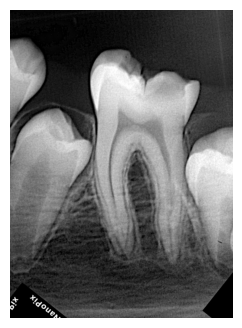

In [45]:

pil_img = Image.open(img_path).convert("RGB")

plt.figure(figsize=(4, 4))
plt.imshow(pil_img)
plt.axis("off")
plt.show()

In [46]:

x = transform(pil_img).unsqueeze(0).to(device)
print("Shape de entrada:", x.shape)

Shape de entrada: torch.Size([1, 1, 128, 128])


In [47]:

with torch.no_grad():
    outputs = model(x)
    probs = torch.softmax(outputs, dim=1)
    pred_idx = torch.argmax(probs, dim=1).item()
    pred_label = class_names[pred_idx]

print("Índice predicho:", pred_idx)
print("Clase predicha:", pred_label)
print("Probabilidades:", probs.squeeze(0).cpu().numpy())

Índice predicho: 5
Clase predicha: 5
Probabilidades: [1.9280935e-03 5.7641999e-04 1.2116951e-04 2.9597276e-01 4.1779687e-05
 7.0129210e-01 6.7665635e-05]


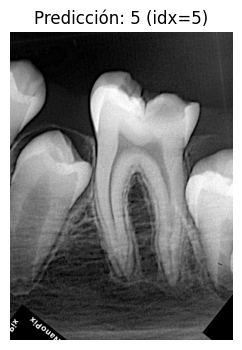

In [48]:

plt.figure(figsize=(4, 4))
plt.imshow(pil_img)
plt.axis("off")
plt.title(f"Predicción: {pred_label} (idx={pred_idx})")
plt.show()

Test the full model

In [49]:

import os
import numpy as np
import pandas as pd
from PIL import Image
from torchvision import transforms
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import matplotlib.pyplot as plt

In [50]:

dataset_root = "FullTest/radiografiamas"
out_size = 128

In [51]:

class_names = sorted([
    d for d in os.listdir(dataset_root)
    if os.path.isdir(os.path.join(dataset_root, d))
])

label_map = {label: idx for idx, label in enumerate(class_names)}
inv_label_map = {v: k for k, v in label_map.items()}

print("Clases encontradas:", class_names)
print("label_map:", label_map)

Clases encontradas: ['Necrosis Pulpar', 'Previamente iniciado', 'Previamente tratado', 'Pulpa Normal', 'Pulpitis irreversible asintomatica', 'Pulpitis irreversible sintomatica', 'Pulpitis reversible']
label_map: {'Necrosis Pulpar': 0, 'Previamente iniciado': 1, 'Previamente tratado': 2, 'Pulpa Normal': 3, 'Pulpitis irreversible asintomatica': 4, 'Pulpitis irreversible sintomatica': 5, 'Pulpitis reversible': 6}


In [52]:

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((out_size, out_size)),
    transforms.ToTensor(),
])

In [53]:

valid_ext = (".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".tif")

samples = []

for class_name in class_names:
    class_dir = os.path.join(dataset_root, class_name)

    for fname in sorted(os.listdir(class_dir)):
        if not fname.lower().endswith(valid_ext):
            continue

        img_path = os.path.join(class_dir, fname)

        samples.append({
            "img_path": img_path,
            "file_name": fname,
            "true_label": class_name,
            "true_idx": label_map[class_name]
        })

df_samples = pd.DataFrame(samples)

print(df_samples.head())
print("Total de imágenes:", len(df_samples))

                                            img_path          file_name  \
0  FullTest/radiografiamas/Necrosis Pulpar/1. OD ...  1. OD 36_aug1.jpg   
1  FullTest/radiografiamas/Necrosis Pulpar/1. OD ...  1. OD 36_aug2.jpg   
2  FullTest/radiografiamas/Necrosis Pulpar/1. OD ...  1. OD 36_aug3.jpg   
3  FullTest/radiografiamas/Necrosis Pulpar/1. OD ...  1. OD 36_aug4.jpg   
4  FullTest/radiografiamas/Necrosis Pulpar/1. OD ...  1. OD 36_aug5.jpg   

        true_label  true_idx  
0  Necrosis Pulpar         0  
1  Necrosis Pulpar         0  
2  Necrosis Pulpar         0  
3  Necrosis Pulpar         0  
4  Necrosis Pulpar         0  
Total de imágenes: 1830


In [54]:

results = []

model = model.to(device)
model.eval()

for _, row in df_samples.iterrows():
    img_path = row["img_path"]
    file_name = row["file_name"]
    true_label = row["true_label"]
    true_idx = row["true_idx"]

    try:
        pil_img = Image.open(img_path).convert("RGB")
        x = transform(pil_img).unsqueeze(0).to(device)

        with torch.no_grad():
            outputs = model(x)
            probs = torch.softmax(outputs, dim=1)
            pred_idx = torch.argmax(probs, dim=1).item()
            pred_label = inv_label_map[pred_idx]

        result = {
            "img_path": img_path,
            "file_name": file_name,
            "true_label": true_label,
            "true_idx": int(true_idx),
            "pred_label": pred_label,
            "pred_idx": int(pred_idx)
        }

        for j, p in enumerate(probs.squeeze(0).cpu().numpy()):
            result[f"prob_class_{j}"] = float(p)

        results.append(result)

    except Exception as e:
        results.append({
            "img_path": img_path,
            "file_name": file_name,
            "true_label": true_label,
            "true_idx": int(true_idx),
            "pred_label": f"ERROR: {e}",
            "pred_idx": None
        })

df_results = pd.DataFrame(results)

print(df_results.head())
print("Total procesadas:", len(df_results))

                                            img_path          file_name  \
0  FullTest/radiografiamas/Necrosis Pulpar/1. OD ...  1. OD 36_aug1.jpg   
1  FullTest/radiografiamas/Necrosis Pulpar/1. OD ...  1. OD 36_aug2.jpg   
2  FullTest/radiografiamas/Necrosis Pulpar/1. OD ...  1. OD 36_aug3.jpg   
3  FullTest/radiografiamas/Necrosis Pulpar/1. OD ...  1. OD 36_aug4.jpg   
4  FullTest/radiografiamas/Necrosis Pulpar/1. OD ...  1. OD 36_aug5.jpg   

        true_label  true_idx    pred_label  pred_idx  prob_class_0  \
0  Necrosis Pulpar         0  Pulpa Normal         3      0.001019   
1  Necrosis Pulpar         0  Pulpa Normal         3      0.000508   
2  Necrosis Pulpar         0  Pulpa Normal         3      0.000694   
3  Necrosis Pulpar         0  Pulpa Normal         3      0.000832   
4  Necrosis Pulpar         0  Pulpa Normal         3      0.001806   

   prob_class_1  prob_class_2  prob_class_3  prob_class_4  prob_class_5  \
0      0.000385      0.000072      0.983333      0.00

In [55]:

df_results.to_csv("predicciones_dataset_por_carpetas.csv", index=False)
print("Archivo guardado: predicciones_dataset_por_carpetas.csv")

Archivo guardado: predicciones_dataset_por_carpetas.csv


In [56]:

df_valid = df_results.dropna(subset=["pred_idx"]).copy()
df_valid = df_valid[df_valid["pred_label"].apply(lambda x: not str(x).startswith("ERROR"))]

y_true = df_valid["true_idx"].astype(int).to_numpy()
y_pred = df_valid["pred_idx"].astype(int).to_numpy()

print("Imágenes válidas para evaluación:", len(df_valid))

Imágenes válidas para evaluación: 1830


In [57]:

acc = accuracy_score(y_true, y_pred)
precision_macro = precision_score(y_true, y_pred, average="macro", zero_division=0)
recall_macro = recall_score(y_true, y_pred, average="macro", zero_division=0)
f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)

precision_weighted = precision_score(y_true, y_pred, average="weighted", zero_division=0)
recall_weighted = recall_score(y_true, y_pred, average="weighted", zero_division=0)
f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)

print("Accuracy:", acc)
print("Precision macro:", precision_macro)
print("Recall macro:", recall_macro)
print("F1 macro:", f1_macro)
print("Precision weighted:", precision_weighted)
print("Recall weighted:", recall_weighted)
print("F1 weighted:", f1_weighted)

Accuracy: 0.20928961748633879
Precision macro: 0.24782771387190355
Recall macro: 0.17123809523809524
F1 macro: 0.08045952241239052
Precision weighted: 0.2340534775170905
Recall weighted: 0.20928961748633879
F1 weighted: 0.10127235376176721


In [58]:

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    zero_division=0
)

print(report)

                                    precision    recall  f1-score   support

                   Necrosis Pulpar       0.33      0.00      0.01       500
              Previamente iniciado       1.00      0.01      0.02       125
               Previamente tratado       0.00      0.00      0.00       215
                      Pulpa Normal       0.21      1.00      0.35       310
Pulpitis irreversible asintomatica       0.00      0.00      0.00       280
 Pulpitis irreversible sintomatica       0.19      0.19      0.19       375
               Pulpitis reversible       0.00      0.00      0.00        25

                          accuracy                           0.21      1830
                         macro avg       0.25      0.17      0.08      1830
                      weighted avg       0.23      0.21      0.10      1830



In [59]:

cm = confusion_matrix(y_true, y_pred)
print(cm)

[[  2   0   0 360   0 138   0]
 [  0   1   0 100   0  24   0]
 [  3   0   0 155   0  57   0]
 [  0   0   0 310   0   0   0]
 [  0   0   0 206   0  74   0]
 [  1   0   0 304   0  70   0]
 [  0   0   0  15   0  10   0]]


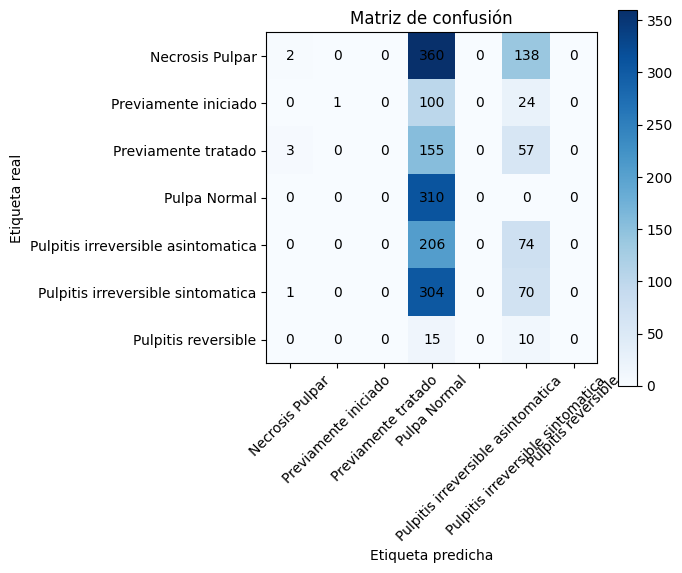

In [60]:

plt.figure(figsize=(7, 6))
plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title("Matriz de confusión")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.ylabel("Etiqueta real")
plt.xlabel("Etiqueta predicha")
plt.tight_layout()
plt.show()

In [61]:

df_errors = df_valid[df_valid["true_idx"] != df_valid["pred_idx"]].copy()
print("Total de errores:", len(df_errors))
print(df_errors[["file_name", "true_label", "pred_label"]].head(20))

Total de errores: 1447
              file_name       true_label    pred_label
0     1. OD 36_aug1.jpg  Necrosis Pulpar  Pulpa Normal
1     1. OD 36_aug2.jpg  Necrosis Pulpar  Pulpa Normal
2     1. OD 36_aug3.jpg  Necrosis Pulpar  Pulpa Normal
3     1. OD 36_aug4.jpg  Necrosis Pulpar  Pulpa Normal
4     1. OD 36_aug5.jpg  Necrosis Pulpar  Pulpa Normal
5    10. OD 16_aug1.jpg  Necrosis Pulpar  Pulpa Normal
6    10. OD 16_aug2.jpg  Necrosis Pulpar  Pulpa Normal
7    10. OD 16_aug3.jpg  Necrosis Pulpar  Pulpa Normal
8    10. OD 16_aug4.jpg  Necrosis Pulpar  Pulpa Normal
9    10. OD 16_aug5.jpg  Necrosis Pulpar  Pulpa Normal
10  100. OD 16_aug1.jpg  Necrosis Pulpar  Pulpa Normal
11  100. OD 16_aug2.jpg  Necrosis Pulpar  Pulpa Normal
12  100. OD 16_aug3.jpg  Necrosis Pulpar  Pulpa Normal
13  100. OD 16_aug4.jpg  Necrosis Pulpar  Pulpa Normal
14  100. OD 16_aug5.jpg  Necrosis Pulpar  Pulpa Normal
15   11. OD 17_aug1.jpg  Necrosis Pulpar  Pulpa Normal
16   11. OD 17_aug2.jpg  Necrosis Pulpar  

In [62]:

print(df_valid["pred_label"].value_counts())

pred_label
Pulpa Normal                         1450
Pulpitis irreversible sintomatica     373
Necrosis Pulpar                         6
Previamente iniciado                    1
Name: count, dtype: int64


In [63]:

per_class_acc = []

for class_name, class_idx in label_map.items():
    df_cls = df_valid[df_valid["true_idx"] == class_idx]
    if len(df_cls) == 0:
        acc_cls = np.nan
    else:
        acc_cls = (df_cls["true_idx"] == df_cls["pred_idx"]).mean()

    per_class_acc.append({
        "class_name": class_name,
        "class_idx": class_idx,
        "n_samples": len(df_cls),
        "accuracy_in_class": acc_cls
    })

df_per_class_acc = pd.DataFrame(per_class_acc)
print(df_per_class_acc)

                           class_name  class_idx  n_samples  accuracy_in_class
0                     Necrosis Pulpar          0        500           0.004000
1                Previamente iniciado          1        125           0.008000
2                 Previamente tratado          2        215           0.000000
3                        Pulpa Normal          3        310           1.000000
4  Pulpitis irreversible asintomatica          4        280           0.000000
5   Pulpitis irreversible sintomatica          5        375           0.186667
6                 Pulpitis reversible          6         25           0.000000
